# EDA 06 — Composite reliability prototype + CV driver model

**Questions.**
1. After EDA 01–05 decomposed sampling error, privacy noise, and imputation, can we combine the two ACS-native pieces — **sampling CV** and **item allocation rate** — into a transparent reliability view that still keeps each component visible?
2. The JL notebook 04 pooled model `log(CV) ~ log(population)` failed (R² ≈ 0). Does a multivariate model that separates **place population** from **estimate size**, and controls for geography level and variable group, explain sampling CV better?

**Headline case.** Median household income at New Jersey tracts. Income CV and income allocation share the same household universe, so the pairing is exact rather than proxy-based.

**What this is / is not.** An exploratory two-axis matrix plus sensitivity checks and a driver model for mentor review. It is **not** an official Census score. Privacy noise (EDA 04) stays out of the ACS row-level score — Decennial DHC remains a separate product track.

**Data.** ACS 5-year 2024 NJ tracts from [`analysis/acs.py`](../analysis/acs.py); allocation rates from [`analysis/alloc.py`](../analysis/alloc.py) (formulas graduated from EDA 05); boundaries via `acs.load_geo`; driver-model helpers from [`analysis/cv_model.py`](../analysis/cv_model.py). Regenerate raw data with the `/ingestion` scripts if needed.

**Thresholds (provisional).**
- CV flag: **0.30** — Census ACS quality-standard convention for estimates unreliable for most uses.
- Allocation flag: **NJ tract 75th percentile** of income allocation — exploratory sample flag, not an official cutoff.

*(Merged 2026-07-31 from the original EDA 06 and EDA 07 notebooks as part of a repo-wide audit-and-trim pass — 07's Composite V2 section now reuses 06's already-computed income reliability frame instead of rebuilding it from scratch; numerically verified identical, no published number changed. See `WORKLOG.md` for the merge record. The original two notebook files are removed.)*

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import acs, alloc, viz
from analysis.composite import (
    QUADRANT_LABELS_PLAIN,
    QUADRANT_ORDER,
    attach_cv_residual_flag,
    build_reliability_frame,
    equal_weight_score,
    quadrant_counts,
    worst_component_score,
)
from analysis.cv_model import (
    build_cv_driver_frame,
    fit_ols,
    incremental_r2,
    model_ready,
)

PROCESSED = REPO_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
KEYS = ["STATE", "COUNTY", "TRACT"]

# Brand palette, shared by every chart in this notebook (previously
# re-declared per chart cell in both source notebooks).
NAVY, GOLD, ICE, BODY, MUTED, FINE = (
    viz.BRAND["NAVY"], viz.BRAND["GOLD"], viz.BRAND["ICE"],
    viz.BRAND["BODY"], viz.BRAND["MUTED"], viz.BRAND["FINE"],
)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\JL_Work_Tree


## 1. Load, join, and derive components

Join ACS estimates to allocation tables 1:1 on STATE/COUNTY/TRACT. Derive income CV (exclude top-coded medians) and income allocation rate. Keep household count as the size axis for the matched-size panel.


In [2]:
tract = acs.load_level("tract")
alloc_raw = alloc.load_level("tract")
alloc_df = alloc.derive_rates(alloc_raw)
geo = acs.load_geo("tract")  # already reprojected to NJ State Plane (EPSG:3424)

assert len(tract) == len(alloc_df) == len(geo) == 2181, (
    len(tract), len(alloc_df), len(geo)
)

rate_cols = [c for c in alloc.RATE_COLUMNS if c != "overall_alloc"]  # county-only
keep_alloc = KEYS + rate_cols + ["B99192_001E", "B99011_001E"]
df = tract.merge(alloc_df[keep_alloc], on=KEYS, how="inner", validate="one_to_one")
gdf = geo[KEYS + ["geometry"]].merge(df, on=KEYS, how="inner", validate="one_to_one")
assert len(gdf) == 2181

# Headline: income CV + income allocation
topcoded = acs.flag_topcoded_income(gdf)
gdf["cv_income"] = acs.cv(gdf["B19013_001E"], gdf["B19013_001M"]).mask(topcoded)
gdf["hh"] = gdf["B99192_001E"]  # household universe for income allocation

# Robustness: poverty CV + family-poverty allocation proxy
gdf["cv_poverty"] = acs.cv(gdf["B17001_002E"], gdf["B17001_002M"])

# Robustness: Black 65+ with handbook zero-cell RSS + age/race allocation diagnostics
gdf["black65_est"] = acs.aggregate_estimate(gdf, acs.BLACK_65PLUS_CELLS)
gdf["black65_moe"] = acs.aggregate_moe(gdf, acs.BLACK_65PLUS_CELLS, zero_rule=True)
gdf["cv_black65"] = acs.cv(gdf["black65_est"], gdf["black65_moe"])

print(f"Top-coded income tracts excluded from CV: {int(topcoded.sum())}")
print(f"Finite income CV: {int(gdf['cv_income'].notna().sum())}")
print(f"Finite income_alloc: {int(gdf['income_alloc'].notna().sum())}")
print(
    f"overall_alloc null share (expect 1.0 at tract): "
    f"{alloc_df['overall_alloc'].isna().mean():.2f}"
)
assert alloc_df["overall_alloc"].isna().all(), "B98031 should be null at tract"
print("Join + component derivation OK")


Top-coded income tracts excluded from CV: 41
Finite income CV: 2109
Finite income_alloc: 2166
overall_alloc null share (expect 1.0 at tract): 1.00
Join + component derivation OK


## 2. Headline matrix — income CV × income allocation

Classify tracts into four quadrants. The **blind spot** is low CV / high allocation: sampling looks fine, but a large share of household income values were imputed.


In [3]:
income_frame, income_thr = build_reliability_frame(
    gdf[["cv_income", "income_alloc", "hh"]].rename(columns={"cv_income": "cv"}),
    cv_col="cv",
    alloc_col="income_alloc",
)
gdf["income_quadrant"] = income_frame["quadrant"].values
gdf["income_equal_weight"] = income_frame["equal_weight_score"].values
gdf["income_worst_component"] = income_frame["worst_component_score"].values

counts = quadrant_counts(gdf["income_quadrant"])
n_classed = int(counts.sum())
print("Provisional thresholds:")
for k, v in income_thr.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"\nClassified tracts: {n_classed}")
for q in QUADRANT_ORDER:
    share = counts[q] / n_classed if n_classed else float("nan")
    print(f"  {QUADRANT_LABELS_PLAIN[q]}: {counts[q]} ({share:.1%})")

blind = counts["low_cv_high_alloc"]
print(
    f"\nBlind-spot share (CV alone would miss high imputation): "
    f"{blind / n_classed:.1%}"
)


Provisional thresholds:
  cv_threshold: 0.3000
  alloc_threshold: 0.4643
  alloc_percentile: 0.7500

Classified tracts: 2109
  Low CV / low allocation: 1522 (72.2%)
  Low CV / high allocation (blind spot): 481 (22.8%)
  High CV / low allocation: 50 (2.4%)
  High CV / high allocation: 56 (2.7%)

Blind-spot share (CV alone would miss high imputation): 22.8%


Chart saved to data\processed\eda06_income_reliability_matrix.png (local-only, regenerable)


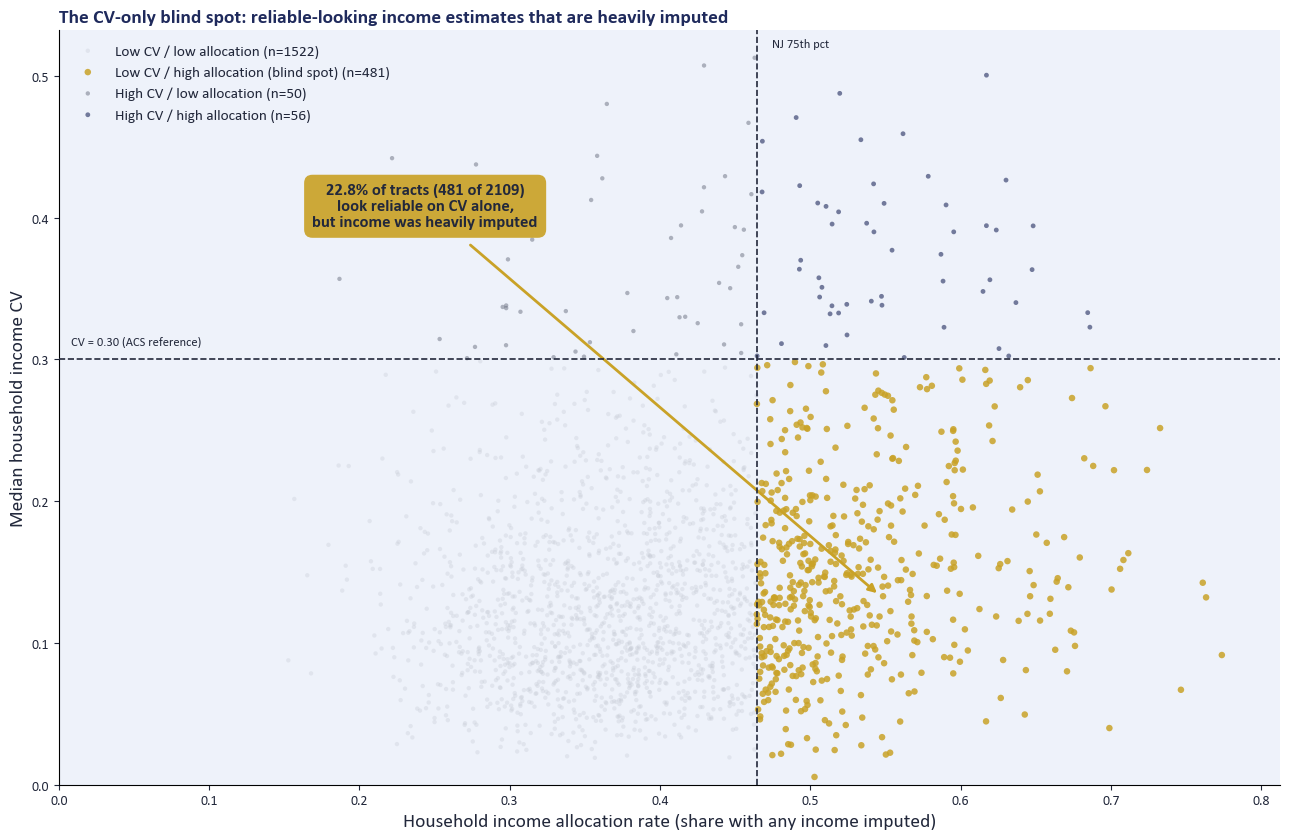

In [4]:
# Scatter matrix, blind spot as the visual focus (palette from the setup cell)
brand_colors = {
    "low_cv_low_alloc": FINE,
    "low_cv_high_alloc": GOLD,
    "high_cv_low_alloc": MUTED,
    "high_cv_high_alloc": NAVY,
}
point_style = {
    "low_cv_low_alloc": dict(s=10, alpha=0.35, zorder=1),
    "high_cv_low_alloc": dict(s=10, alpha=0.45, zorder=2),
    "high_cv_high_alloc": dict(s=12, alpha=0.6, zorder=3),
    "low_cv_high_alloc": dict(s=22, alpha=0.85, zorder=4),
}
colors = brand_colors  # shared with the section-3 map so both stay on-brand

with plt.rc_context({"font.family": "Calibri"}):
    fig, ax = plt.subplots(figsize=(13, 8.5))
    ax.set_facecolor(ICE)
    plot = gdf.dropna(subset=["cv_income", "income_alloc", "income_quadrant"])
    for q in QUADRANT_ORDER:
        sub = plot[plot["income_quadrant"] == q]
        ax.scatter(
            sub["income_alloc"],
            sub["cv_income"],
            c=brand_colors[q],
            label=f"{QUADRANT_LABELS_PLAIN[q]} (n={len(sub)})",
            edgecolors="none",
            **point_style[q],
        )
    ax.axhline(income_thr["cv_threshold"], color=BODY, ls="--", lw=1.2, zorder=5)
    ax.axvline(income_thr["alloc_threshold"], color=BODY, ls="--", lw=1.2, zorder=5)
    ax.text(
        0.01, income_thr["cv_threshold"] + 0.01, "CV = 0.30 (ACS reference)",
        transform=ax.get_yaxis_transform(), fontsize=9, color=BODY,
    )
    ax.text(
        income_thr["alloc_threshold"] + 0.01, 0.99, "NJ 75th pct",
        transform=ax.get_xaxis_transform(), fontsize=9, color=BODY, va="top", ha="left",
    )

    blind_share = blind / n_classed
    ax.annotate(
        f"{blind_share:.1%} of tracts ({blind} of {n_classed})\n"
        "look reliable on CV alone,\nbut income was heavily imputed",
        xy=(0.55, 0.13), xycoords="data",
        xytext=(0.30, 0.74), textcoords="axes fraction",
        fontsize=12, fontweight="bold", color=BODY, ha="center",
        bbox=dict(boxstyle="round,pad=0.5", fc=GOLD, ec="none", alpha=0.92),
        arrowprops=dict(arrowstyle="-|>", color=GOLD, lw=2, shrinkA=8, shrinkB=8),
    )

    ax.set_xlabel("Household income allocation rate (share with any income imputed)", fontsize=14, color=BODY)
    ax.set_ylabel("Median household income CV", fontsize=14, color=BODY)
    ax.set_title(
        "The CV-only blind spot: reliable-looking income estimates that are heavily imputed",
        fontsize=14, color=NAVY, fontweight="bold", loc="left",
    )
    ax.legend(loc="upper left", fontsize=11, frameon=False, labelcolor=BODY)
    ax.set_xlim(0, min(1.05, plot["income_alloc"].max() * 1.05))
    ax.set_ylim(0, min(1.0, plot["cv_income"].quantile(0.995) * 1.15))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=BODY)
    fig.tight_layout()
    viz.save_chart(fig, REPO_ROOT, "eda06_income_reliability_matrix.png", dpi=150)
    plt.show()


## 3. Map — where do the quadrants land?


Chart saved to data\processed\eda06_income_quadrant_map.png (local-only, regenerable)


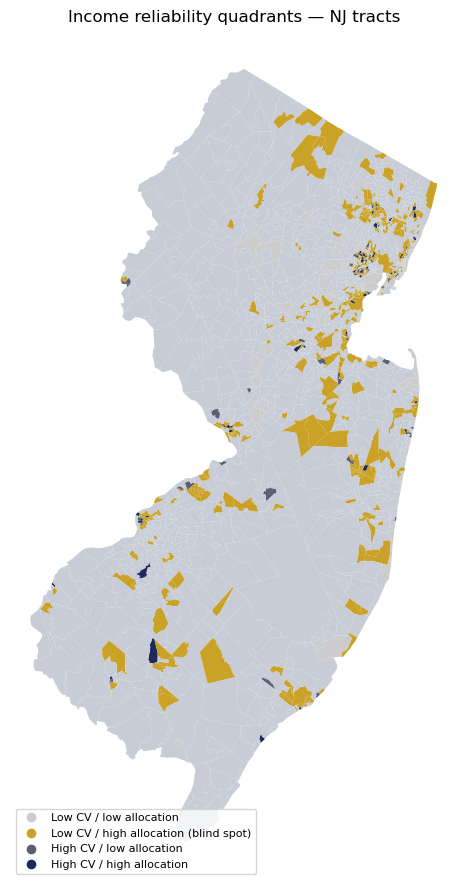

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 9))
gdf_plot = gdf.copy()
gdf_plot["color"] = gdf_plot["income_quadrant"].map(colors).fillna("#cccccc")
gdf_plot.plot(color=gdf_plot["color"], ax=ax, edgecolor="none", linewidth=0)
ax.set_axis_off()
ax.set_title("Income reliability quadrants — NJ tracts")
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors[q],
        markersize=8,
        label=QUADRANT_LABELS_PLAIN[q],
    )
    for q in QUADRANT_ORDER
]
ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=True)
fig.tight_layout()
viz.save_chart(fig, REPO_ROOT, "eda06_income_quadrant_map.png", dpi=150)
plt.show()


## 4. Matched-size validation

Within household-count bins, tracts of similar size can still land in different quadrants. This connects EDA 02/05 (size matters for CV and confounds raw correlations) to the composite view: size alone does not determine the allocation axis.


,hh_bin,n,hh_median,alloc_p25,alloc_p75,alloc_iqr,blind_spot_share,high_both_share
0,Q1 smallest,529,937.0,0.349,0.494,0.145,0.299,0.038
1,Q2,526,1388.0,0.325,0.479,0.153,0.259,0.030
2,Q3,527,1772.0,0.340,0.464,0.124,0.228,0.021
3,Q4 largest,527,2370.0,0.321,0.433,0.112,0.127,0.017


Chart saved to data\processed\eda06_matched_size_validation.png (local-only, regenerable)


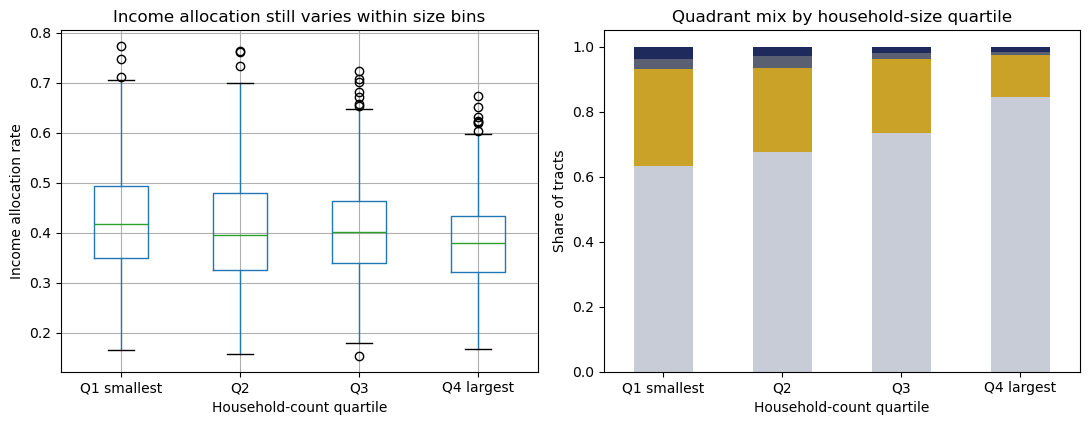

Matched-size check: allocation IQR > 0.05 in every household quartile


In [6]:
valid = gdf.dropna(subset=["hh", "income_alloc", "cv_income", "income_quadrant"]).copy()
valid = valid[valid["hh"] > 0]
valid["hh_bin"] = pd.qcut(
    valid["hh"], q=4, labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"]
)

rows = []
for b, sub in valid.groupby("hh_bin", observed=True):
    qc = quadrant_counts(sub["income_quadrant"])
    rows.append(
        {
            "hh_bin": str(b),
            "n": len(sub),
            "hh_median": sub["hh"].median(),
            "alloc_p25": sub["income_alloc"].quantile(0.25),
            "alloc_p75": sub["income_alloc"].quantile(0.75),
            "alloc_iqr": sub["income_alloc"].quantile(0.75)
            - sub["income_alloc"].quantile(0.25),
            "blind_spot_share": qc["low_cv_high_alloc"] / len(sub),
            "high_both_share": qc["high_cv_high_alloc"] / len(sub),
        }
    )
size_panel = pd.DataFrame(rows)
display(size_panel.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
valid.boxplot(column="income_alloc", by="hh_bin", ax=axes[0])
axes[0].set_title("Income allocation still varies within size bins")
axes[0].set_xlabel("Household-count quartile")
axes[0].set_ylabel("Income allocation rate")
plt.suptitle("")
share = (
    valid.groupby(["hh_bin", "income_quadrant"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=list(QUADRANT_ORDER), fill_value=0)
)
share = share.div(share.sum(axis=1), axis=0)
share.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[colors[q] for q in QUADRANT_ORDER],
    legend=False,
)
axes[1].set_title("Quadrant mix by household-size quartile")
axes[1].set_xlabel("Household-count quartile")
axes[1].set_ylabel("Share of tracts")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
viz.save_chart(fig, REPO_ROOT, "eda06_matched_size_validation.png", dpi=150)
plt.show()

assert (size_panel["alloc_iqr"] > 0.05).all(), (
    "expected meaningful within-bin allocation spread"
)
print("Matched-size check: allocation IQR > 0.05 in every household quartile")


## 5. Sensitivity — equal-weight vs worst-component

Transform CV and allocation to within-sample percentile risk, then compare mean vs max. Report reclassification of the top-risk quartile rather than locking in permanent weights.


In [7]:
sens = gdf.dropna(subset=["cv_income", "income_alloc"]).copy()
sens["eq"] = equal_weight_score(sens["cv_income"], sens["income_alloc"])
sens["worst"] = worst_component_score(sens["cv_income"], sens["income_alloc"])

eq_top = sens["eq"] >= sens["eq"].quantile(0.75)
worst_top = sens["worst"] >= sens["worst"].quantile(0.75)
agree = (eq_top == worst_top).mean()
only_eq = int((eq_top & ~worst_top).sum())
only_worst = int((worst_top & ~eq_top).sum())
print(f"Top-quartile agreement (equal-weight vs worst-component): {agree:.1%}")
print(f"  In equal-weight top-Q only: {only_eq}")
print(f"  In worst-component top-Q only: {only_worst}")
print(f"  In both: {int((eq_top & worst_top).sum())}")

low_cv = sens[sens["cv_income"] <= income_thr["cv_threshold"]]
flagged_by_worst = (low_cv["worst"] >= sens["worst"].quantile(0.75)).mean()
print(
    f"\nAmong low-CV tracts, share still in worst-component top quartile: "
    f"{flagged_by_worst:.1%}"
)
print("(This is the sensitivity view of the blind-spot problem.)")


Top-quartile agreement (equal-weight vs worst-component): 84.6%
  In equal-weight top-Q only: 162
  In worst-component top-Q only: 162
  In both: 366

Among low-CV tracts, share still in worst-component top quartile: 21.1%
(This is the sensitivity view of the blind-spot problem.)


## 6. Robustness cases (explicitly labeled)

- **Poverty:** person-level poverty CV paired with **family-universe** allocation proxy (`fam_pov_alloc`) — not an exact pairing.
- **Black 65+:** handbook zero-cell RSS CV paired with age/race allocation means as **diagnostic** axes — no age×race income-style allocation table for this subgroup.


In [8]:
def summarize_case(name, cv_s, alloc_s, alloc_label):
    frame, thr = build_reliability_frame(
        pd.DataFrame({"cv": cv_s, "alloc": alloc_s}),
        cv_col="cv",
        alloc_col="alloc",
    )
    case_counts = quadrant_counts(frame["quadrant"])
    n = int(case_counts.sum())
    print(f"\n=== {name} ===")
    print(f"Allocation axis: {alloc_label}")
    print(
        f"CV threshold={thr['cv_threshold']:.2f}; "
        f"alloc 75th={thr['alloc_threshold']:.4f}"
    )
    print(f"Classified n={n}")
    for q in QUADRANT_ORDER:
        print(
            f"  {QUADRANT_LABELS_PLAIN[q]}: "
            f"{case_counts[q]} ({case_counts[q]/n:.1%})"
        )
    print(f"Blind-spot share: {case_counts['low_cv_high_alloc']/n:.1%}")
    return frame, thr, case_counts


_, _, pov_counts = summarize_case(
    "Poverty (PROXY pairing)",
    gdf["cv_poverty"],
    gdf["fam_pov_alloc"],
    "fam_pov_alloc (family universe — labeled proxy)",
)

demo_diag = gdf[["age_alloc", "race_alloc"]].mean(axis=1)
_, _, b65_counts = summarize_case(
    "Black 65+ (DIAGNOSTIC allocation axis)",
    gdf["cv_black65"],
    demo_diag,
    "mean(age_alloc, race_alloc) — not a subgroup-specific allocation table",
)

print(
    "\nNote: robustness cases illustrate method portability; "
    "income remains the headline exact pairing."
)



=== Poverty (PROXY pairing) ===
Allocation axis: fam_pov_alloc (family universe — labeled proxy)
CV threshold=0.30; alloc 75th=0.4979
Classified n=2158
  Low CV / low allocation: 287 (13.3%)
  Low CV / high allocation (blind spot): 142 (6.6%)
  High CV / low allocation: 1332 (61.7%)
  High CV / high allocation: 397 (18.4%)
Blind-spot share: 6.6%

=== Black 65+ (DIAGNOSTIC allocation axis) ===
Allocation axis: mean(age_alloc, race_alloc) — not a subgroup-specific allocation table
CV threshold=0.30; alloc 75th=0.0193
Classified n=1596
  Low CV / low allocation: 133 (8.3%)
  Low CV / high allocation (blind spot): 67 (4.2%)
  High CV / low allocation: 1058 (66.3%)
  High CV / high allocation: 338 (21.2%)
Blind-spot share: 4.2%

Note: robustness cases illustrate method portability; income remains the headline exact pairing.


## 7. What drives sampling CV? Long analysis frame

One row per geography × variable group. Poverty and Black 65+ are tract/county only (null at block group in this pull). Income uses household count as estimate size.


In [9]:
frame = build_cv_driver_frame()
ready = model_ready(frame)

print("Raw rows:", len(frame))
print("Model-ready rows:", len(ready))
print("\nCoverage:")
display(
    ready.groupby(["level", "variable_group"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["variable_group", "level"])
)

# Income must never use dollar medians as estimate_size.
income_ready = ready[ready["variable_group"] == "income"]
assert income_ready["estimate_size"].median() < 50_000, (
    "income estimate_size looks like dollars, not households"
)
print(
    "Income estimate_size median (households):",
    float(income_ready["estimate_size"].median()),
)


Raw rows: 35218
Model-ready rows: 24947

Coverage:


,level,variable_group,n
2,county,black65_agg,21
6,tract,black65_agg,1596
3,county,black65_cell,122
7,tract,black65_cell,4411
0,block_group,income,5785
4,county,income,21
8,tract,income,2109
1,block_group,population,6528
9,tract,population,2172
5,county,poverty,21


Income estimate_size median (households): 626.0


## 7a. Nested OLS models

1. **A** — `log(CV) ~ log(place_pop)` (JL failure reproduction)
2. **B** — `log(CV) ~ log(estimate_size)`
3. **Full** — place pop + estimate size + level + variable group
4. **Interaction** — full + `log(estimate_size) × variable group`


In [10]:
models = [
    fit_ols(ready, ["log_place_pop"], name="A_place_pop"),
    fit_ols(ready, ["log_estimate_size"], name="B_estimate_size"),
    fit_ols(
        ready,
        [
            "log_place_pop",
            "log_estimate_size",
            "C(level)",
            "C(variable_group)",
        ],
        name="C_full",
    ),
    fit_ols(
        ready,
        [
            "log_place_pop",
            "log_estimate_size",
            "C(level)",
            "C(variable_group)",
            "log_estimate_size:C(variable_group)",
        ],
        name="D_interaction",
    ),
]

r2_table = incremental_r2(models)
display(r2_table.round(4))

print("\nKey coefficients (full model):")
display(models[2].coefficients.round(4))

assert models[0].r_squared < 0.05, "place-pop-only R2 should stay near zero"
assert models[2].r_squared > models[0].r_squared + 0.15, (
    "full model should beat place-pop baseline substantially"
)
assert models[1].r_squared > models[0].r_squared, (
    "estimate size alone should beat place population alone"
)
print("Nested-model assertions passed.")


,model,r_squared,incremental_r2,n_obs
0,A_place_pop,0.0051,0.0051,24947
1,B_estimate_size,0.6661,0.6610,24947
2,C_full,0.7062,0.0401,24947
3,D_interaction,0.7260,0.0198,24947



Key coefficients (full model):


intercept            0.8630
log_place_pop        0.0597
log_estimate_size   -0.3509
level_county        -1.4999
level_tract         -0.4203
var_black65_cell    -0.0912
var_income          -0.6764
var_population      -0.5049
var_poverty          0.0748
Name: coefficient, dtype: float64

Nested-model assertions passed.


Chart saved to data\processed\eda07_r2_waterfall.png (local-only, regenerable)


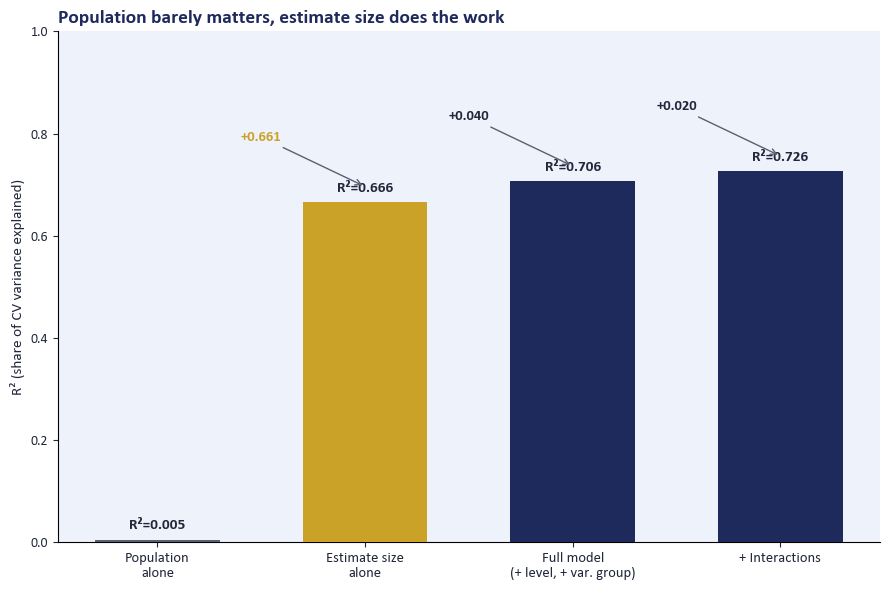

In [11]:
model_labels = {
    "A_place_pop": "Population\nalone",
    "B_estimate_size": "Estimate size\nalone",
    "C_full": "Full model\n(+ level, + var. group)",
    "D_interaction": "+ Interactions",
}
bar_colors = [MUTED, GOLD, NAVY, NAVY]

with plt.rc_context({"font.family": "Calibri"}):
    fig, ax = plt.subplots(figsize=(9, 6))

    # R² waterfall — each bar is that model's total R², labeled with what
    # was added relative to the previous step.
    ax.set_facecolor(ICE)
    x = np.arange(len(r2_table))
    heights = r2_table["r_squared"].to_list()
    deltas = r2_table["incremental_r2"].to_list()
    labels = [model_labels[m] for m in r2_table["model"]]

    ax.bar(x, heights, color=bar_colors, width=0.6, zorder=3)
    for xi, h in zip(x, heights):
        ax.text(xi, h + 0.02, f"R²={h:.3f}", ha="center", fontsize=11, color=BODY, fontweight="bold")
    for i in range(1, len(x)):
        mid_x = (x[i - 1] + x[i]) / 2
        mid_y = max(heights[i - 1], heights[i]) + 0.12
        ax.annotate(
            f"+{deltas[i]:.3f}",
            xy=(x[i], heights[i] + 0.03), xytext=(mid_x, mid_y),
            fontsize=10.5, color=GOLD if i == 1 else BODY, fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1),
        )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10.5, color=BODY)
    ax.set_ylabel("R² (share of CV variance explained)", fontsize=11, color=BODY)
    ax.set_ylim(0, min(1.0, max(heights) * 1.4))
    ax.set_title(
        "Population barely matters, estimate size does the work",
        fontsize=14, color=NAVY, fontweight="bold", loc="left",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=BODY)

    fig.tight_layout()
    viz.save_chart(fig, REPO_ROOT, "eda07_r2_waterfall.png", dpi=150)
    plt.show()


## 8. Matched estimate-size panel (population / poverty / Black 65+)

Compare Black 65+ aggregate, poverty counts, and total population **within shared estimate-size bins** at tract level. Matched on magnitude, not demographic twins.


,variable_group,size_bin,n,median_estimate,median_cv,share_cv_le_0_30
0,black65_agg,Q1 smallest,1130,29.0,0.800,0.004
1,black65_agg,Q2,409,186.0,0.334,0.357
2,black65_agg,Q3,57,557.0,0.225,0.860
3,population,Q1 smallest,5,35.0,0.760,0.200
4,population,Q2,2,124.0,0.236,1.000
5,population,Q3,684,2680.0,0.093,1.000
6,population,Q4 largest,1481,4814.0,0.075,0.999
7,poverty,Q1 smallest,353,63.0,0.513,0.042
8,poverty,Q2,1069,223.0,0.397,0.127
9,poverty,Q3,738,695.0,0.322,0.377


Chart saved to data\processed\eda07_matched_estimate_size.png (local-only, regenerable)


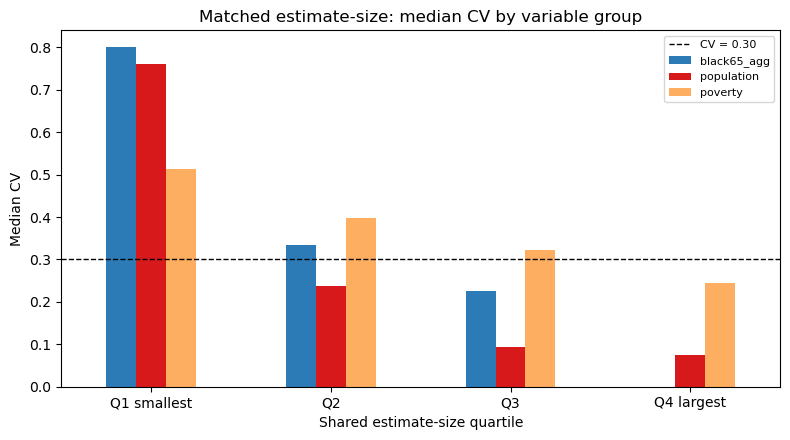

Mid-bin mean of median CVs — population: 0.165; black65_agg: 0.279
Matched-size assertion passed.


In [12]:
tract = ready[
    (ready["level"] == "tract")
    & (ready["variable_group"].isin(["population", "poverty", "black65_agg"]))
].copy()

# Shared bins from the pooled estimate-size distribution of the three groups.
tract["size_bin"] = pd.qcut(
    tract["estimate_size"],
    q=4,
    labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
    duplicates="drop",
)

rows = []
for (grp, b), sub in tract.groupby(["variable_group", "size_bin"], observed=True):
    rows.append(
        {
            "variable_group": grp,
            "size_bin": str(b),
            "n": len(sub),
            "median_estimate": sub["estimate_size"].median(),
            "median_cv": sub["cv"].median(),
            "share_cv_le_0_30": (sub["cv"] <= 0.30).mean(),
        }
    )
matched = pd.DataFrame(rows)
display(matched.round(3))

# Pivot for chart: median CV by bin × group
pivot = matched.pivot(
    index="size_bin", columns="variable_group", values="median_cv"
).reindex(["Q1 smallest", "Q2", "Q3", "Q4 largest"])

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind="bar", ax=ax, color=["#2c7bb6", "#d7191c", "#fdae61"])
ax.axhline(0.30, color="black", ls="--", lw=1, label="CV = 0.30")
ax.set_ylabel("Median CV")
ax.set_xlabel("Shared estimate-size quartile")
ax.set_title("Matched estimate-size: median CV by variable group")
ax.legend(title="", fontsize=8)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
viz.save_chart(fig, REPO_ROOT, "eda07_matched_estimate_size.png", dpi=150)
plt.show()

# Within overlapping mid bins, Black 65+ should be noisier than population
# if size alone does not fully explain subgroup CV.
mid = matched[matched["size_bin"].isin(["Q2", "Q3"])]
pop_mid = mid.loc[mid["variable_group"] == "population", "median_cv"].mean()
b65_mid = mid.loc[mid["variable_group"] == "black65_agg", "median_cv"].mean()
print(f"Mid-bin mean of median CVs — population: {pop_mid:.3f}; black65_agg: {b65_mid:.3f}")
assert b65_mid > pop_mid, (
    "expected Black 65+ noisier than population in matched mid-size bins"
)
print("Matched-size assertion passed.")


## 9. Composite V2 — income residual flag on the sampling axis

Keep the Section 2 matrix (reuses `income_frame`, not a fresh reload/rejoin). Add `cv_residual_high`: income CV worse than predicted from household-universe size. Allocation axis unchanged; no DHC privacy join.


In [13]:
rel, resid_meta = attach_cv_residual_flag(
    income_frame, cv_col="cv", estimate_size_col="hh"
)

print("Matrix thresholds:", {k: round(v, 4) for k, v in income_thr.items()})
print("Residual model:", {k: round(v, 4) if isinstance(v, float) else v for k, v in resid_meta.items()})
print(f"cv_residual_high share: {rel['cv_residual_high'].mean():.1%}")

# Among high-CV tracts, how often is the CV *unexpected* given HH size?
high_cv = rel["cv"] > income_thr["cv_threshold"]
print(
    "Among high-CV tracts, residual-high share:",
    f"{rel.loc[high_cv, 'cv_residual_high'].mean():.1%}",
)
# Blind-spot tracts that are also residual-high (sampling looks fine but
# imputation high; residual flag should be rare there by construction).
blind_v2 = rel["quadrant"] == "low_cv_high_alloc"
print(
    "Blind-spot tracts also residual-high:",
    f"{rel.loc[blind_v2, 'cv_residual_high'].mean():.1%}",
)

assert int(quadrant_counts(rel["quadrant"]).sum()) > 2000
assert rel["cv_residual_high"].any()
print("Composite V2 assertions passed.")

Matrix thresholds: {'cv_threshold': 0.3, 'alloc_threshold': 0.4643, 'alloc_percentile': 0.75}
Residual model: {'r_squared': 0.0113, 'residual_threshold': 0.3608, 'residual_percentile': 0.75, 'n_train': 2109.0, 'slope_log_estimate_size': -0.1434}
cv_residual_high share: 24.2%
Among high-CV tracts, residual-high share: 100.0%
Blind-spot tracts also residual-high: 28.3%
Composite V2 assertions passed.


## 10. Findings (plain English)

**Composite matrix (Section 2-6):**
1. **Two axes stay visible.** The income matrix keeps sampling CV and imputation rate as separate coordinates. Equal-weight / worst-component scores are sensitivity checks, not replacements for the matrix.
2. **CV alone misses a real blind spot.** A substantial share of classified tracts have CV ≤ 0.30 but income allocation above the exploratory NJ 75th percentile — these look "fine" on MOE-based CV yet have high imputation.
3. **Size does not collapse the allocation axis.** Within household-count quartiles, income allocation still spreads (IQR stays material) and quadrant mixes differ — matching EDA 05's size-controlled independence story.
4. **Combination rule matters at the margin.** Equal-weight and worst-component disagree on who sits in the top-risk quartile; report that disagreement rather than pretending weights are settled.

**CV driver model (Section 7-9):**
5. **Place population alone still fails** in the pooled frame (R² ≈ 0.005) — reproducing the JL Final Takeaway.
6. **Estimate size dominates the pooled model** (R² jumps to ≈ 0.67 alone; full model ≈ 0.71; interaction ≈ 0.73). Variable group and geography level add smaller but real incremental R².
7. **Matched estimate-size bins:** in mid-size quartiles, Black 65+ median CV stays higher than population (~0.28 vs ~0.17). Size matters, but table/variable structure still matters. (Population barely appears in the smallest shared bins because tract populations are large.)
8. **Composite V2:** keep the CV × allocation matrix. The income `cv_residual_high` flag is implemented as a tooltip seed, but the income-only size model has **very low R² (~0.01)** — household count does not predict income CV the way count-size predicts count CVs. For income, residual flags largely track raw high CV; they are more informative for count variables.

**Prototype boundaries (both sections).** Thresholds and weights are provisional. Privacy noise is not row-joined. Poverty and Black 65+ are labeled robustness/diagnostic cases, not exact pairings.

### Mentor decisions needed
- Tier philosophy: keep the visible two-axis matrix, or collapse to a single weighted score for the dashboard?
- Keep empirical DHC privacy RMSE as a **separate product score**, not mixed into ACS rows?
- Accept proxy/diagnostic pairings for poverty and Black 65+ in the concept pitch, with labels?
- Prefer residual-based sampling flags (best for count estimates) alongside raw CV tiers, or raw CV only for the dashboard — especially for income medians?

In [14]:
# Final assertions for clean re-run (unchanged from the pre-merge EDA 06 notebook;
# EDA 07's assertions already ran inline in Sections 7-9 above).
assert n_classed > 2000
assert counts["low_cv_high_alloc"] > 0
assert 0 < agree < 1
print("EDA 06 + EDA 07 verification assertions passed.")
print("Charts:", sorted(p.name for p in PROCESSED.glob("eda0[67]_*.png")))

EDA 06 + EDA 07 verification assertions passed.
Charts: ['eda06_income_quadrant_map.png', 'eda06_income_reliability_matrix.png', 'eda06_matched_size_validation.png', 'eda07_matched_estimate_size.png', 'eda07_r2_waterfall.png']
